In [730]:
import os
import json
import dill
import torch
import unicodedata
import numpy as np
import pandas as pd
from datasets import Dataset
from evaluate import load
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    BertTokenizerFast,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer,
    pipeline
)


In [731]:
# with open("../data/labeled_data.json", "r", encoding="utf-8") as f:
#     data1 = json.load(f)
# data1[0]

with open("../data/frases_rotuladas.json", "r", encoding="utf-8") as f:
    data2 = json.load(f)
data2[0]

# data = data1 + data2
# len(data), len(data1), len(data2)

data = data2



In [732]:
data[0]


{'text': 'se fechar R$ 774 eu levo hoje',
 'id': 1,
 'entities': [{'start': 10, 'end': 16, 'text': 'R$ 774', 'labels': ['VALOR']},
  {'start': 20, 'end': 24, 'text': 'levo', 'labels': ['PAGAMENTO']}],
 'orientacao': [{'start': 10,
   'end': 16,
   'text': 'R$ 774',
   'labels': ['positiva']},
  {'start': 20, 'end': 24, 'text': 'levo', 'labels': ['positiva']}],
 'modalidade': [{'start': 10,
   'end': 16,
   'text': 'R$ 774',
   'labels': ['condicional']},
  {'start': 20, 'end': 24, 'text': 'levo', 'labels': ['condicional']}],
 'referencia_temporal': [{'start': 10,
   'end': 16,
   'text': 'R$ 774',
   'labels': ['presente']},
  {'start': 20, 'end': 24, 'text': 'levo', 'labels': ['presente']}]}

In [733]:
records = []
for item in data:
    try:
        for i, ent in enumerate(item["entities"]):
            records.append({
                "text":                        item["text"],
                "start":                       ent["start"],
                "end":                         ent["end"],
                "entity_label":                ent["labels"][0],
                "referencia_temporal_label":   item["referencia_temporal"][i]["labels"][0],
                "modalidade_label":            item["modalidade"][i]["labels"][0],
                "orientacao_label":            item["orientacao"][i]["labels"][0],
            })
    except Exception as e:
        print(f"Error: {e}, {item}")
len(records)


2584

In [734]:
records[0]


{'text': 'se fechar R$ 774 eu levo hoje',
 'start': 10,
 'end': 16,
 'entity_label': 'VALOR',
 'referencia_temporal_label': 'presente',
 'modalidade_label': 'condicional',
 'orientacao_label': 'positiva'}

In [735]:
df = pd.DataFrame(records)
df.head()


,text,start,end,entity_label,referencia_temporal_label,modalidade_label,orientacao_label
0,se fechar R$ 774 eu levo hoje,10,16,VALOR,presente,condicional,positiva
1,se fechar R$ 774 eu levo hoje,20,24,PAGAMENTO,presente,condicional,positiva
2,"se baixar pra R$ 2253,00 eu levo",14,24,VALOR,presente,condicional,positiva
3,"se baixar pra R$ 2253,00 eu levo",28,32,PAGAMENTO,presente,condicional,positiva
4,não tenho R$200 hoje mas amanhã mando,10,15,VALOR,presente,negado,negativa


In [736]:
for input_ids, attention_mask in zip(ds_enc[0]['input_ids'], ds_enc[0]['attention_mask']):
    if attention_mask == 1:
        print(f"input_ids: {input_ids:10} |  attention_mask: {attention_mask:10}")


input_ids:        101 |  attention_mask:          1
input_ids:        395 |  attention_mask:          1
input_ids:        303 |  attention_mask:          1
input_ids:       1335 |  attention_mask:          1
input_ids:        109 |  attention_mask:          1
input_ids:      21789 |  attention_mask:          1
input_ids:      22334 |  attention_mask:          1
input_ids:       3302 |  attention_mask:          1
input_ids:        125 |  attention_mask:          1
input_ids:       1335 |  attention_mask:          1
input_ids:        109 |  attention_mask:          1
input_ids:       2334 |  attention_mask:          1
input_ids:        102 |  attention_mask:          1


In [737]:
def preprocessar_texto(texto):
    if not isinstance(texto, str):
        return texto
    texto = texto.lower()
    texto = unicodedata.normalize('NFKD', texto)
    texto = ''.join([c for c in texto if not unicodedata.combining(c)])
    # texto = re.sub(r'[^\w\s]', ' ', texto)
    # texto = re.sub(r'\s+', ' ', texto).strip()
    
    return texto


In [738]:
df["text"] = df["text"].apply(preprocessar_texto)
df.head()


,text,start,end,entity_label,referencia_temporal_label,modalidade_label,orientacao_label
0,se fechar r$ 774 eu levo hoje,10,16,VALOR,presente,condicional,positiva
1,se fechar r$ 774 eu levo hoje,20,24,PAGAMENTO,presente,condicional,positiva
2,"se baixar pra r$ 2253,00 eu levo",14,24,VALOR,presente,condicional,positiva
3,"se baixar pra r$ 2253,00 eu levo",28,32,PAGAMENTO,presente,condicional,positiva
4,nao tenho r$200 hoje mas amanha mando,10,15,VALOR,presente,negado,negativa


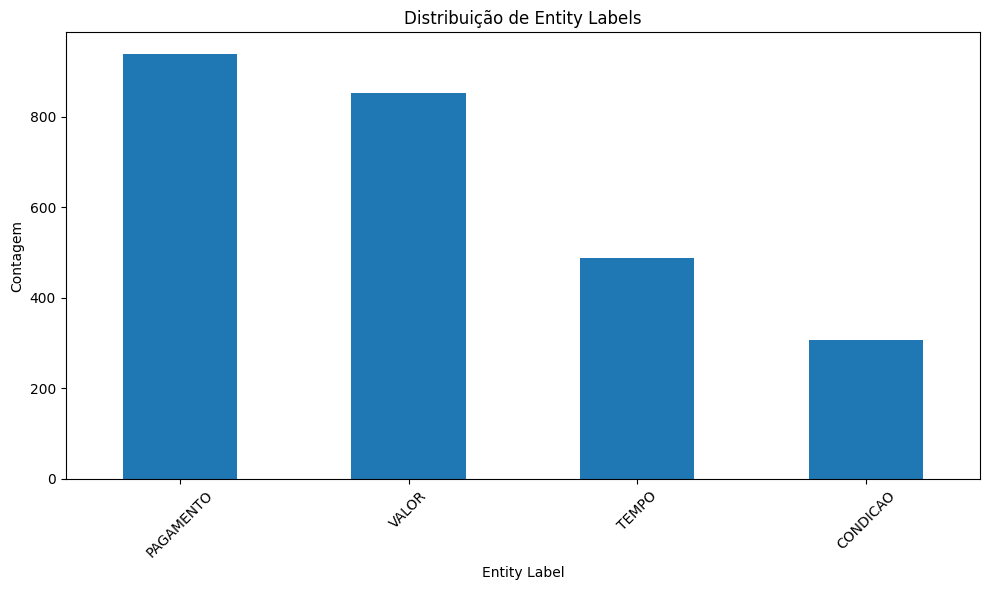

In [739]:
plt.figure(figsize=(10,6))
df['entity_label'].value_counts().plot(kind='bar')
plt.title('Distribuição de Entity Labels')
plt.xlabel('Entity Label')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [740]:
df_entity = df[['text', 'start', 'end', 'entity_label']]
df_entity.head()


,text,start,end,entity_label
0,se fechar r$ 774 eu levo hoje,10,16,VALOR
1,se fechar r$ 774 eu levo hoje,20,24,PAGAMENTO
2,"se baixar pra r$ 2253,00 eu levo",14,24,VALOR
3,"se baixar pra r$ 2253,00 eu levo",28,32,PAGAMENTO
4,nao tenho r$200 hoje mas amanha mando,10,15,VALOR


In [741]:
def to_iob_tags(group):
    text = group.name
    labels = ["O"] * len(text)
    for _, row in group.iterrows():
        for i in range(row.start, row.end):
            prefix = "B-" if i == row.start else "I-"
            labels[i] = prefix + row.entity_label
    return pd.DataFrame({"text": text, "tags": [labels]})


In [742]:
iob_df = (
    df_entity
    .groupby("text", sort=False)
    .apply(to_iob_tags)
    .reset_index(drop=True)
)
iob_df.head()


C:\Users\knd\AppData\Local\Temp\ipykernel_15768\1260785468.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(to_iob_tags)


,text,tags
0,se fechar r$ 774 eu levo hoje,"[O, O, O, O, O, O, O, O, O, O, B-VALOR, I-VALO..."
1,"se baixar pra r$ 2253,00 eu levo","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, B-V..."
2,nao tenho r$200 hoje mas amanha mando,"[O, O, O, O, O, O, O, O, O, O, B-VALOR, I-VALO..."
3,da pra fazer uns 350 reais?,"[O, O, O, O, O, O, O, O, O, O, O, O, O, B-VALO..."
4,"eu nao consigo r$ 80,00","[O, O, O, O, O, O, O, B-PAGAMENTO, I-PAGAMENTO..."


In [743]:
iob_df["words"] = iob_df["text"].str.split()

def chars_to_word_tags(text, char_tags):
    words = text.split()
    tags = []
    idx = 0
    for w in words:
        chunk = char_tags[idx : idx + len(w)]
        tag = next((t for t in chunk if t != "O"), "O")
        tags.append(tag)
        idx += len(w) + 1
    return tags

iob_df["word_tags"] = iob_df.apply(
    lambda row: chars_to_word_tags(row["text"], row["tags"]), axis=1
)


In [744]:
iob_df.head()


,text,tags,words,word_tags
0,se fechar r$ 774 eu levo hoje,"[O, O, O, O, O, O, O, O, O, O, B-VALOR, I-VALO...","[se, fechar, r$, 774, eu, levo, hoje]","[O, O, B-VALOR, I-VALOR, O, B-PAGAMENTO, O]"
1,"se baixar pra r$ 2253,00 eu levo","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, B-V...","[se, baixar, pra, r$, 2253,00, eu, levo]","[O, O, O, B-VALOR, I-VALOR, O, B-PAGAMENTO]"
2,nao tenho r$200 hoje mas amanha mando,"[O, O, O, O, O, O, O, O, O, O, B-VALOR, I-VALO...","[nao, tenho, r$200, hoje, mas, amanha, mando]","[O, O, B-VALOR, B-TEMPO, O, B-TEMPO, B-PAGAMENTO]"
3,da pra fazer uns 350 reais?,"[O, O, O, O, O, O, O, O, O, O, O, O, O, B-VALO...","[da, pra, fazer, uns, 350, reais?]","[O, O, O, B-VALOR, I-VALOR, I-VALOR]"
4,"eu nao consigo r$ 80,00","[O, O, O, O, O, O, O, B-PAGAMENTO, I-PAGAMENTO...","[eu, nao, consigo, r$, 80,00]","[O, O, B-PAGAMENTO, B-VALOR, I-VALOR]"


In [745]:
iob_df.describe()


,text,tags,words,word_tags
count,953,953,953,953
unique,953,613,953,153
top,se fechar r$ 774 eu levo hoje,"[B-PAGAMENTO, I-PAGAMENTO, I-PAGAMENTO, I-PAGA...","[se, fechar, r$, 774, eu, levo, hoje]","[B-PAGAMENTO, B-VALOR, I-VALOR]"
freq,1,7,1,85


In [746]:
letters = [x for x in iob_df.iloc[0].text]
labels  = [x for x in iob_df.iloc[0].tags]

for letter, label in zip(letters, labels):
    print(f"{letter} | {label}")


s | O
e | O
  | O
f | O
e | O
c | O
h | O
a | O
r | O
  | O
r | B-VALOR
$ | I-VALOR
  | I-VALOR
7 | I-VALOR
7 | I-VALOR
4 | I-VALOR
  | O
e | O
u | O
  | O
l | B-PAGAMENTO
e | I-PAGAMENTO
v | I-PAGAMENTO
o | I-PAGAMENTO
  | O
h | O
o | O
j | O
e | O


In [747]:
iob_df = iob_df.drop(columns=["text", "tags"])


In [748]:
for i in range(20):
    letters = [x for x in iob_df.iloc[i].words]
    labels  = [x for x in iob_df.iloc[i].word_tags]

    for letter, label in zip(letters, labels):
        print(f"{letter:12} | {label}")
    print(f'{"="*30}')


se           | O
fechar       | O
r$           | B-VALOR
774          | I-VALOR
eu           | O
levo         | B-PAGAMENTO
hoje         | O
se           | O
baixar       | O
pra          | O
r$           | B-VALOR
2253,00      | I-VALOR
eu           | O
levo         | B-PAGAMENTO
nao          | O
tenho        | O
r$200        | B-VALOR
hoje         | B-TEMPO
mas          | O
amanha       | B-TEMPO
mando        | B-PAGAMENTO
da           | O
pra          | O
fazer        | O
uns          | B-VALOR
350          | I-VALOR
reais?       | I-VALOR
eu           | O
nao          | O
consigo      | B-PAGAMENTO
r$           | B-VALOR
80,00        | I-VALOR
posso        | B-PAGAMENTO
r$           | B-VALOR
3987         | I-VALOR
final        | B-TEMPO
do           | I-TEMPO
mes          | I-TEMPO
com          | O
desconto     | B-CONDICAO
eu           | O
aceito       | B-PAGAMENTO
nao          | O
consigo      | B-PAGAMENTO
132          | B-VALOR
tenho        | B-PAGAMENTO
uns          | B-VALO

In [749]:
train_df = iob_df.sample(frac=0.8, random_state=42)
eval_df  = iob_df.drop(train_df.index)

len(train_df),len(eval_df)


(762, 191)

In [750]:
train_ds = Dataset.from_pandas(train_df)
eval_ds  = Dataset.from_pandas(eval_df)

len(train_df),len(eval_df)


(762, 191)

In [751]:
checkpoint = "neuralmind/bert-base-portuguese-cased"
tokenizer = BertTokenizerFast.from_pretrained(checkpoint)


In [752]:
unique_tags = []
for tag_list in iob_df["word_tags"]:
    for tag in tag_list:
        if tag not in unique_tags:
            unique_tags.append(tag)
unique_tags


['O',
 'B-VALOR',
 'I-VALOR',
 'B-PAGAMENTO',
 'B-TEMPO',
 'I-TEMPO',
 'B-CONDICAO',
 'I-CONDICAO']

In [753]:
tag2id = {
    'O': 0,
    'B-TEMPO': 1,
    'I-TEMPO': 2,
    'B-PAGAMENTO': 3,
    'I-PAGAMENTO': 4,
    'B-VALOR': 5,
    'I-VALOR': 6,
    'B-CONDICAO': 7,
    'I-CONDICAO': 8,
}
id2tag = {idx: tag for tag, idx in tag2id.items()}

tag2id, id2tag


({'O': 0,
  'B-TEMPO': 1,
  'I-TEMPO': 2,
  'B-PAGAMENTO': 3,
  'I-PAGAMENTO': 4,
  'B-VALOR': 5,
  'I-VALOR': 6,
  'B-CONDICAO': 7,
  'I-CONDICAO': 8},
 {0: 'O',
  1: 'B-TEMPO',
  2: 'I-TEMPO',
  3: 'B-PAGAMENTO',
  4: 'I-PAGAMENTO',
  5: 'B-VALOR',
  6: 'I-VALOR',
  7: 'B-CONDICAO',
  8: 'I-CONDICAO'})

In [754]:
def encode_and_align_labels_word(examples):
    tokenized = tokenizer(
        examples["words"],
        is_split_into_words=True,
        truncation=True,
        padding="max_length",
        max_length=128,
    )
    all_labels = []
    for batch_idx in range(len(tokenized["input_ids"])):
        word_ids = tokenized.word_ids(batch_index=batch_idx)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            else:
                tag = examples["word_tags"][batch_idx][word_idx]
                # primeiro sub-token → mantém B-*, sub-tokens seguintes → converte B-* em I-*
                if word_idx != previous_word_idx:
                    label_id = tag2id[tag]
                else:
                    if tag.startswith("B-"):
                        tag = "I-" + tag.split("-", 1)[1]
                    label_id = tag2id[tag]
                label_ids.append(label_id)
            previous_word_idx = word_idx
        all_labels.append(label_ids)
    tokenized["labels"] = all_labels
    return tokenized


In [755]:
train_encodings = train_ds.map(
    encode_and_align_labels_word,
    batched=True,
    remove_columns=["words", "word_tags"]
)
eval_encodings = eval_ds.map(
    encode_and_align_labels_word,
    batched=True,
    remove_columns=["words", "word_tags"]
)

train_encodings.features


Map: 100%|██████████| 191/191 [00:00<00:00, 2850.17 examples/s]


{'__index_level_0__': Value(dtype='int64', id=None),
 'input_ids': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None),
 'token_type_ids': Sequence(feature=Value(dtype='int8', id=None), length=-1, id=None),
 'attention_mask': Sequence(feature=Value(dtype='int8', id=None), length=-1, id=None),
 'labels': Sequence(feature=Value(dtype='int64', id=None), length=-1, id=None)}

In [756]:
frase = train_encodings[0]
for input_ids, labels, attention_mask in zip(frase['input_ids'], frase['labels'], frase['attention_mask']):
    if attention_mask == 1:
        print(f"input_ids: {input_ids:12} | label id: {labels:12} | equivalente: {id2tag[labels] if labels != -100 else '[PAD]':12} | attention_mask: {attention_mask:10}")



input_ids:          101 | label id:         -100 | equivalente: [PAD]        | attention_mask:          1
input_ids:        17891 | label id:            0 | equivalente: O            | attention_mask:          1
input_ids:        18024 | label id:            3 | equivalente: B-PAGAMENTO  | attention_mask:          1
input_ids:         1335 | label id:            5 | equivalente: B-VALOR      | attention_mask:          1
input_ids:          109 | label id:            6 | equivalente: I-VALOR      | attention_mask:          1
input_ids:         2939 | label id:            6 | equivalente: I-VALOR      | attention_mask:          1
input_ids:        22313 | label id:            6 | equivalente: I-VALOR      | attention_mask:          1
input_ids:          173 | label id:            1 | equivalente: B-TEMPO      | attention_mask:          1
input_ids:          542 | label id:            2 | equivalente: I-TEMPO      | attention_mask:          1
input_ids:         1564 | label id:           

In [757]:
frase = train_encodings[0]
for input_ids, labels, attention_mask in zip(frase['input_ids'], frase['labels'], frase['attention_mask']):
    if attention_mask == 1:
        print(f"input_ids: {input_ids:12} | label id: {labels:12} | equivalente: {id2tag[labels] if labels != -100 else '[PAD]':12} | attention_mask: {attention_mask:10}")



input_ids:          101 | label id:         -100 | equivalente: [PAD]        | attention_mask:          1
input_ids:        17891 | label id:            0 | equivalente: O            | attention_mask:          1
input_ids:        18024 | label id:            3 | equivalente: B-PAGAMENTO  | attention_mask:          1
input_ids:         1335 | label id:            5 | equivalente: B-VALOR      | attention_mask:          1
input_ids:          109 | label id:            6 | equivalente: I-VALOR      | attention_mask:          1
input_ids:         2939 | label id:            6 | equivalente: I-VALOR      | attention_mask:          1
input_ids:        22313 | label id:            6 | equivalente: I-VALOR      | attention_mask:          1
input_ids:          173 | label id:            1 | equivalente: B-TEMPO      | attention_mask:          1
input_ids:          542 | label id:            2 | equivalente: I-TEMPO      | attention_mask:          1
input_ids:         1564 | label id:           

In [758]:
exemplo = train_encodings[0]
tokens = tokenizer.convert_ids_to_tokens(exemplo['input_ids'])
labels = exemplo['labels']

print("Alinhamento token-label:")
print("-" * 30)
for token, label in zip(tokens, labels):
    if label != -100:
        print(f"{token:20} | {id2tag[label]}")

from collections import Counter
labels_validas = [l for l in labels if l != -100]
dist_labels = Counter(id2tag[l] for l in labels_validas)

print("\nDistribuição das labels:")
print("-" * 30)
for label, count in dist_labels.items():
    print(f"{label:20} | {count:}")


Alinhamento token-label:
------------------------------
vou                  | O
mandar               | B-PAGAMENTO
r                    | B-VALOR
$                    | I-VALOR
29                   | I-VALOR
##2                  | I-VALOR
em                   | B-TEMPO
18                   | I-TEMPO
dias                 | I-TEMPO

Distribuição das labels:
------------------------------
O                    | 1
B-PAGAMENTO          | 1
B-VALOR              | 1
I-VALOR              | 3
B-TEMPO              | 1
I-TEMPO              | 2


In [759]:
model = AutoModelForTokenClassification.from_pretrained(
    checkpoint,
    num_labels=len(id2tag.keys()),  
    id2label=id2tag,        
    label2id=tag2id    
)


Some weights of BertForTokenClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [760]:
data_collator = DataCollatorForTokenClassification(tokenizer)


In [761]:

training_args = TrainingArguments(
    output_dir="./bert-ner",
    do_train=True,
    do_eval=True,
    eval_strategy="epoch",   
    logging_strategy="steps",   
    save_strategy="steps",    
    eval_steps=200,             
    logging_steps=50,           
    save_steps=200,             
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    learning_rate=3e-5,
    weight_decay=0.01,
    no_cuda=False,
    use_cpu=False,
)


In [762]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_encodings,
    eval_dataset=eval_encodings,
    tokenizer=tokenizer,
    data_collator=data_collator,
)


C:\Users\knd\AppData\Local\Temp\ipykernel_15768\2257340954.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [763]:
trainer.train()


Epoch,Training Loss,Validation Loss
1,No log,0.462863
2,No log,0.112187
3,0.721900,0.045033
4,0.721900,0.034086
5,0.059800,0.029861


TrainOutput(global_step=120, training_loss=0.3305330082774162, metrics={'train_runtime': 766.387, 'train_samples_per_second': 4.971, 'train_steps_per_second': 0.157, 'total_flos': 248900911879680.0, 'train_loss': 0.3305330082774162, 'epoch': 5.0})

In [764]:
metrics = trainer.evaluate()
metrics



{'eval_loss': 0.029860714450478554,
 'eval_runtime': 5.4117,
 'eval_samples_per_second': 35.294,
 'eval_steps_per_second': 1.109,
 'epoch': 5.0}

In [765]:
metric = load("seqeval")


In [766]:
def strip_prefix(tag):
    return tag if tag == "O" else tag.split("-", 1)[1]

def align_predictions(predictions, label_ids):
    preds = np.argmax(predictions, axis=2)
    batch_size, seq_len = preds.shape

    true_labels = []
    true_preds  = []
    for i in range(batch_size):
        curr_preds  = []
        curr_labels = []
        for j in range(seq_len):
            if label_ids[i, j] != -100:
                pred_tag = id2tag[preds[i, j]]
                true_tag = id2tag[label_ids[i, j]]
                curr_preds.append(strip_prefix(pred_tag))
                curr_labels.append(strip_prefix(true_tag))
        true_preds.append(curr_preds)
        true_labels.append(curr_labels)
    return true_preds, true_labels


In [767]:
predictions, label_ids, _ = trainer.predict(eval_encodings)



In [768]:
true_preds, true_labels = align_predictions(predictions, label_ids)


In [769]:
for i in range(5):
    print("SENTENÇA:", ' '.join(eval_ds[i]["words"]))
    print("Word         | True         | Pred")
    print("_"*40)
    for word, true, pred in zip(eval_ds[i]["words"], true_labels[i], true_preds[i]):
        print(f"{word}{(12-len(word))*' '} | {true}{(12-len(true))*' '} | {pred}")
    print(f'{"="*40}')
    print(f'')
    
    


SENTENÇA: se baixar pra r$ 2253,00 eu levo
Word         | True         | Pred
________________________________________
se           | O            | O
baixar       | O            | O
pra          | O            | O
r$           | O            | O
2253,00      | VALOR        | VALOR
eu           | VALOR        | VALOR
levo         | VALOR        | VALOR

SENTENÇA: eu nao consigo r$ 80,00
Word         | True         | Pred
________________________________________
eu           | O            | O
nao          | O            | O
consigo      | O            | O
r$           | PAGAMENTO    | PAGAMENTO
80,00        | VALOR        | VALOR

SENTENÇA: quando cair na conta transfiro 800 reais
Word         | True         | Pred
________________________________________
quando       | O            | O
cair         | CONDICAO     | CONDICAO
na           | CONDICAO     | CONDICAO
conta        | CONDICAO     | CONDICAO
transfiro    | PAGAMENTO    | PAGAMENTO
800          | PAGAMENTO    | PAGAMENTO
reais

In [770]:
results = metric.compute(predictions=true_preds, references=true_labels)

print({k: v for k, v in results.items() if k.endswith("f1")})
print({k: v for k, v in results.items() if k.endswith("precision")})
print({k: v for k, v in results.items() if k.endswith("recall")})


{'overall_f1': 0.9938775510204082}
{'overall_precision': 0.9938775510204082}
{'overall_recall': 0.9938775510204082}


c:\Users\knd\repos\study\POLI\NLP\t1\.venv\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: VALOR seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
c:\Users\knd\repos\study\POLI\NLP\t1\.venv\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: PAGAMENTO seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
c:\Users\knd\repos\study\POLI\NLP\t1\.venv\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: CONDICAO seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
c:\Users\knd\repos\study\POLI\NLP\t1\.venv\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: TEMPO seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))


In [771]:
ner = pipeline(
    "token-classification",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)


Device set to use cuda:0


In [772]:
frase = "eu nao vou conseguir pagar esse mes, mas consigo pagar no proximo se tiver algum desconto"

result = ner(frase)
for ent in result:
    print(f"{ent['word']:30} → {ent['entity_group']:30} score: {ent['score']:.2f}") 


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


conseguir                      → PAGAMENTO                      score: 0.87
pagar                          → PAGAMENTO                      score: 0.95
esse mes                       → TEMPO                          score: 0.99
consigo                        → PAGAMENTO                      score: 0.97
pagar                          → PAGAMENTO                      score: 0.96
no proximo                     → TEMPO                          score: 0.98
algum desconto                 → CONDICAO                       score: 0.82


In [773]:
ds = Dataset.from_pandas(df)
ds[0]


{'text': 'se fechar r$ 774 eu levo hoje',
 'start': 10,
 'end': 16,
 'entity_label': 'VALOR',
 'referencia_temporal_label': 'presente',
 'modalidade_label': 'condicional',
 'orientacao_label': 'positiva'}

In [774]:
def encode_and_extract_spans(examples):
    tokenized = tokenizer(
        examples["text"],
        return_offsets_mapping=True,
        truncation=True,
        padding="max_length",
        max_length=128,
    )
    span_token_indices = []
    for i, offsets in enumerate(tokenized["offset_mapping"]):
        s, e = examples["start"][i], examples["end"][i]
        idxs = []
        for j, (st, en) in enumerate(offsets):
            if st == 0 and en == 0:
                continue
            if st < e and en > s:
                idxs.append(j)
        span_token_indices.append(idxs)
    tokenized["span_token_indices"] = span_token_indices
    tokenized.pop("offset_mapping")
    return tokenized

ds_enc = ds.map(encode_and_extract_spans, batched=True)


Map:   0%|          | 0/2584 [00:00<?, ? examples/s]

Map: 100%|██████████| 2584/2584 [00:00<00:00, 5003.65 examples/s]


In [775]:
ds_enc[0]['text']


'se fechar r$ 774 eu levo hoje'

In [776]:
for input_ids, attention_mask in zip(ds_enc[0]['input_ids'], ds_enc[0]['attention_mask']):
    if attention_mask == 1:
        print(f"input_ids: {input_ids:10} |  attention_mask: {attention_mask:10}")


input_ids:        101 |  attention_mask:          1
input_ids:        176 |  attention_mask:          1
input_ids:      16325 |  attention_mask:          1
input_ids:       1335 |  attention_mask:          1
input_ids:        109 |  attention_mask:          1
input_ids:      14332 |  attention_mask:          1
input_ids:      22336 |  attention_mask:          1
input_ids:       2779 |  attention_mask:          1
input_ids:       1301 |  attention_mask:          1
input_ids:      22280 |  attention_mask:          1
input_ids:       1790 |  attention_mask:          1
input_ids:        102 |  attention_mask:          1


In [777]:
ent_labels = ds_enc["entity_label"]

ohe = OneHotEncoder(sparse_output=False).fit(
    [[lbl] for lbl in ent_labels]
)

onehots = ohe.transform([[lbl] for lbl in ent_labels]).tolist()

ds_enc = ds_enc.add_column(
    "entity_onehot",
    onehots
)


In [778]:
print(ds_enc.column_names)
print(ds_enc[0]["entity_onehot"])


['text', 'start', 'end', 'entity_label', 'referencia_temporal_label', 'modalidade_label', 'orientacao_label', 'input_ids', 'token_type_ids', 'attention_mask', 'span_token_indices', 'entity_onehot']
[0.0, 0.0, 0.0, 1.0]


In [779]:
target_cols = [
    "referencia_temporal_label",
    "modalidade_label",
    "orientacao_label",
]
encoders = {}
for col in target_cols:
    le = LabelEncoder().fit(ds_enc[col])
    encoders[col] = le
    ds_enc = ds_enc.add_column(
        f"{col}_id",
        le.transform(ds_enc[col]).tolist()
    )


In [780]:
ds_enc.column_names, ds_enc[0]['orientacao_label_id']


(['text',
  'start',
  'end',
  'entity_label',
  'referencia_temporal_label',
  'modalidade_label',
  'orientacao_label',
  'input_ids',
  'token_type_ids',
  'attention_mask',
  'span_token_indices',
  'entity_onehot',
  'referencia_temporal_label_id',
  'modalidade_label_id',
  'orientacao_label_id'],
 1)

In [781]:
def extract_entity_features(bert_model, input_ids, attention_mask, span_indices, entity_onehot):
    device = next(bert_model.parameters()).device
    with torch.no_grad():
        outputs = bert_model(
            input_ids=torch.tensor(input_ids).unsqueeze(0).to(device),
            attention_mask=torch.tensor(attention_mask).unsqueeze(0).to(device),
            
        )
        hidden_states = outputs.last_hidden_state[0]  # [seq_len, 768]
    
    # 1. EMBEDDING DA FRASE TODA (token CLS)
    sentence_embedding = hidden_states[0]  # [768] - token [CLS]
    
    # 2. EMBEDDING DA ENTIDADE ESPECÍFICA  
    if len(span_indices) > 0:
        entity_embedding = hidden_states[span_indices].mean(dim=0)  # [768]
    else:
        entity_embedding = torch.zeros(768, device=device)
    
    # 3. CONTEXTO LOCAL (tokens ao redor da entidade)
    context_start = max(0, span_indices[0] - 2)
    context_end = min(len(hidden_states), span_indices[0] + 3)
    context_embedding = hidden_states[context_start:context_end].mean(dim=0)  # [768]
    
    # 4. TIPO DA ENTIDADE
    entity_type = torch.tensor(entity_onehot, dtype=torch.float32, device=device)  # [4]
    
    # 5. CONCATENAR TUDO
    features = torch.cat([
        sentence_embedding,   # 768 - contexto global
        entity_embedding,     # 768 - entidade específica  
        context_embedding,    # 768 - contexto local
        entity_type          # 4   - tipo da entidade
    ])  # Total: 768 + 768 + 768 + 4 = 2308 dimensões
    
    return features


In [782]:
features = extract_entity_features(
    model.bert,
    ds_enc[0]['input_ids'],
    ds_enc[0]['attention_mask'], 
    ds_enc[0]['span_token_indices'],
    ds_enc[0]['entity_onehot']
)
features.shape, features[:5]


(torch.Size([2308]),
 tensor([-0.4024, -0.8546, -0.0909,  0.0281,  0.5212], device='cuda:0'))

In [783]:
def process_example(example):
    features = extract_entity_features(
        model.bert,
        example['input_ids'],
        example['attention_mask'], 
        example['span_token_indices'],
        example['entity_onehot']
    )
    
    return {
        'features': features.cpu().numpy(),
        'labels': [
            example['referencia_temporal_label_id'],
            example['modalidade_label_id'],
            example['orientacao_label_id']
        ]
    }


In [784]:
ds_features = ds_enc.map(process_example, desc="Extraindo features")


Extraindo features: 100%|██████████| 2584/2584 [02:21<00:00, 18.25 examples/s]


In [785]:
def expand_features_and_labels(example):
    feature_dict = {f'feature_{i}': example['features'][i] for i in range(len(example['features']))}
    
    label_dict = {
        'referencia_temporal': example['labels'][0],
        'modalidade': example['labels'][1], 
        'orientacao': example['labels'][2]
    }
    return {**feature_dict, **label_dict}


In [786]:
ds = ds_features.map(expand_features_and_labels)


Map: 100%|██████████| 2584/2584 [00:26<00:00, 97.95 examples/s] 


In [787]:
len(ds.column_names)


2328

In [788]:
ds = ds.remove_columns(['text',
                        'start',
                        'end',
                        'entity_label',
                        'referencia_temporal_label',
                        'modalidade_label',
                        'orientacao_label',
                        'input_ids',
                        'token_type_ids',
                        'attention_mask',
                        'span_token_indices',
                        'entity_onehot',
                        'referencia_temporal_label_id',
                        'modalidade_label_id',
                        'orientacao_label_id',
                        'features',
                        'labels',])


In [789]:
len(ds.column_names)


2311

In [790]:
label_columns = ds.column_names[-3:]

X = ds.remove_columns(label_columns)
y = ds.select_columns(label_columns)

X.shape, y.shape


((2584, 2308), (2584, 3))

In [791]:
X_array = np.array(X.to_pandas())
y_array = np.array(y.to_pandas())

X_array[0][0]


-0.4023878276348114

In [792]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_array)

pca = PCA(n_components=0.95, ) 
X_reduced = pca.fit_transform(X_scaled)

print(f"Dimensões originais: {X.shape[1]}") 
print(f"Dimensões reduzidas: {X_reduced.shape[1]}")
print(f"Variância explicada: {pca.explained_variance_ratio_.sum():.2f}")


Dimensões originais: 2308
Dimensões reduzidas: 79
Variância explicada: 0.95


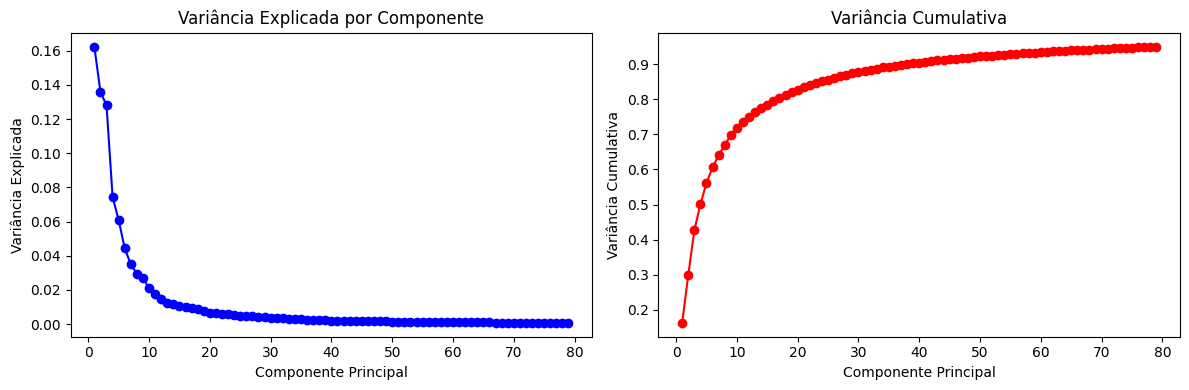

In [793]:

size = X_reduced.shape[1] 
# Explicação da variância por componente
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, size + 1), pca.explained_variance_ratio_[:size], 'bo-')
plt.title('Variância Explicada por Componente')
plt.xlabel('Componente Principal')
plt.ylabel('Variância Explicada')

plt.subplot(1, 2, 2)
plt.plot(range(1, size + 1), pca.explained_variance_ratio_[:size].cumsum(), 'ro-')
plt.title('Variância Cumulativa')
plt.xlabel('Componente Principal')
plt.ylabel('Variância Cumulativa')
plt.tight_layout()
plt.show()


In [794]:
X_reduced


array([[-20.01211719,   5.4945031 ,  16.37431771, ...,  -0.68055485,
         -0.50600007,  -0.97237953],
       [  9.78055789, -13.27220784,  -0.52683212, ...,   0.22496462,
         -0.95991162,  -1.87108361],
       [-21.94936135,   5.20559209,  16.93201448, ...,   0.95822674,
         -1.65903406,   1.31693414],
       ...,
       [ 12.25602483, -18.27547664,  -8.16594532, ...,   2.62843654,
         -1.02188932,   0.71823477],
       [  0.03525195, -22.92359974, -11.53093172, ...,   3.31421092,
          0.34193246,  -0.50893805],
       [-27.81105714,   1.98735456,   4.21175874, ...,   0.66550134,
         -1.10166862,   1.13948916]])

In [795]:
X_reduced.shape, y_array.shape


((2584, 79), (2584, 3))

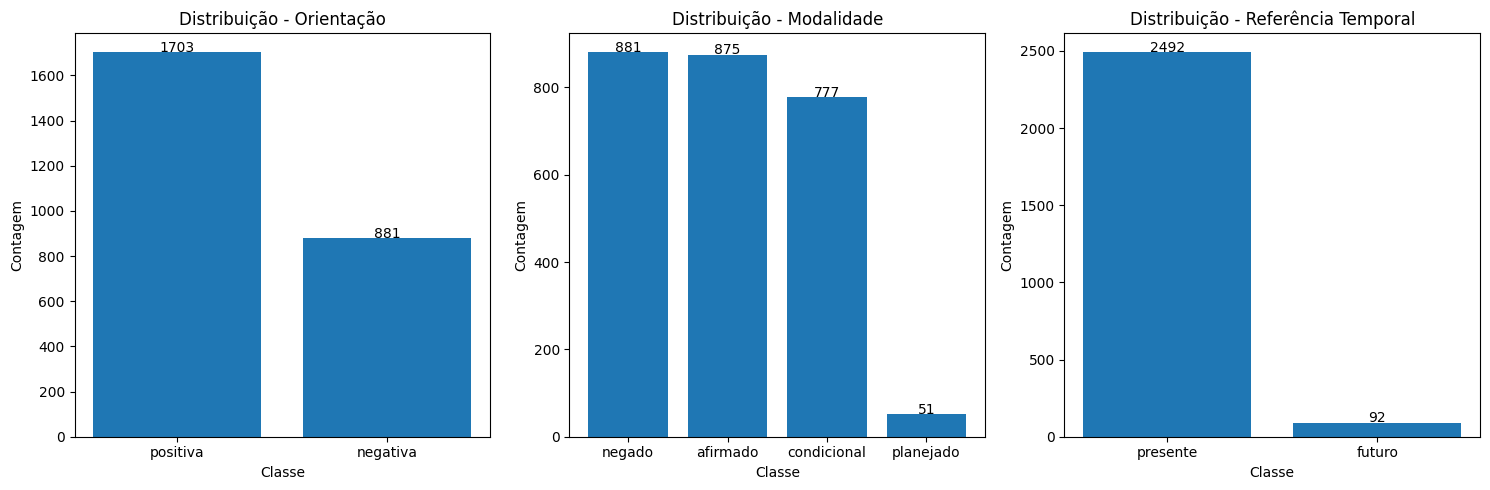

In [796]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Orientação
orientacao_counts = pd.Series(ds_enc['orientacao_label']).value_counts()
axes[0].bar(orientacao_counts.index, orientacao_counts.values)
axes[0].set_title('Distribuição - Orientação')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Contagem')
for i, v in enumerate(orientacao_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center')

# Modalidade  
modalidade_counts = pd.Series(ds_enc['modalidade_label']).value_counts()
axes[1].bar(modalidade_counts.index, modalidade_counts.values)
axes[1].set_title('Distribuição - Modalidade')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Contagem')
for i, v in enumerate(modalidade_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha='center')

# Referência Temporal
temporal_counts = pd.Series(ds_enc['referencia_temporal_label']).value_counts()
axes[2].bar(temporal_counts.index, temporal_counts.values)
axes[2].set_title('Distribuição - Referência Temporal')
axes[2].set_xlabel('Classe')
axes[2].set_ylabel('Contagem')
for i, v in enumerate(temporal_counts.values):
    axes[2].text(i, v + 0.5, str(v), ha='center')

plt.tight_layout()
plt.show()


In [797]:
def calculate_class_weights(y_array):
    weights_dict = {}
    
    for i, label_name in enumerate(['referencia_temporal', 'modalidade', 'orientacao']):
        classes = np.unique(y_array[:, i])
        weights = compute_class_weight(
            class_weight='balanced',
            classes=classes,
            y=y_array[:, i]
        )
        weights_dict[label_name] = dict(zip(classes, weights))
        
        unique, counts = np.unique(y_array[:, i], return_counts=True)
        print(f"\n{label_name}:")
        for cls, count, weight in zip(unique, counts, weights):
            print(f"  Classe {cls}: {count:3} amostras → peso {weight:.3f}")
    
    return weights_dict


In [798]:
class_weights = calculate_class_weights(y_array)
class_weights



referencia_temporal:
  Classe 0:  92 amostras → peso 14.043
  Classe 1: 2492 amostras → peso 0.518

modalidade:
  Classe 0: 875 amostras → peso 0.738
  Classe 1: 777 amostras → peso 0.831
  Classe 2: 881 amostras → peso 0.733
  Classe 3:  51 amostras → peso 12.667

orientacao:
  Classe 0: 881 amostras → peso 1.467
  Classe 1: 1703 amostras → peso 0.759


{'referencia_temporal': {0: 14.043478260869565, 1: 0.5184590690208668},
 'modalidade': {0: 0.7382857142857143,
  1: 0.8314028314028314,
  2: 0.7332576617480137,
  3: 12.666666666666666},
 'orientacao': {0: 1.4665153234960273, 1: 0.7586611861421022}}

In [799]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y_array, test_size=0.2, random_state=42, #stratify=y_array balancear mais antes de usar
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((2067, 79), (517, 79), (2067, 3), (517, 3))

In [800]:

classifiers = {
    'referencia_temporal': LogisticRegression(
        max_iter=1000,
        C=0.01,
        class_weight=class_weights['referencia_temporal']
    ),
    'modalidade': LogisticRegression(
        max_iter=1000,
        C=0.01,
        class_weight=class_weights['modalidade'] 
    ),
    'orientacao': LogisticRegression(
        max_iter=1000,
        C=0.01,
        class_weight=class_weights['orientacao']
    )
}

predictions = {}
for i, (task_name, clf) in enumerate(classifiers.items()):
    print(f"Treinando {task_name}...")
    clf.fit(X_train, y_train[:, i])
    predictions[task_name] = clf.predict(X_test)


print("\nBASELINE - Logistic Regression COM CLASS WEIGHTS:")
for i, task_name in enumerate(['referencia_temporal', 'modalidade', 'orientacao']):
    print(f"\n{task_name.upper()}:")
    print(classification_report(y_test[:, i], predictions[task_name]))


Treinando referencia_temporal...
Treinando modalidade...


Treinando orientacao...

BASELINE - Logistic Regression COM CLASS WEIGHTS:

REFERENCIA_TEMPORAL:
              precision    recall  f1-score   support

           0       0.72      1.00      0.84        23
           1       1.00      0.98      0.99       494

    accuracy                           0.98       517
   macro avg       0.86      0.99      0.91       517
weighted avg       0.99      0.98      0.98       517


MODALIDADE:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       159
           1       1.00      1.00      1.00       165
           2       1.00      0.99      1.00       176
           3       1.00      1.00      1.00        17

    accuracy                           1.00       517
   macro avg       1.00      1.00      1.00       517
weighted avg       1.00      1.00      1.00       517


ORIENTACAO:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       176
      

In [801]:
for task_name, clf in classifiers.items():
    task_idx = ['referencia_temporal', 'modalidade', 'orientacao'].index(task_name)
    
    cv_scores = cross_val_score(
        clf, X_reduced, y_array[:, task_idx], 
        cv=5, scoring='f1_macro'
    )
    
    print(f"\n{task_name.upper()}:")
    print(f"  CV F1-macro: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")



REFERENCIA_TEMPORAL:
  CV F1-macro: 0.899 ± 0.031

MODALIDADE:
  CV F1-macro: 0.997 ± 0.003

ORIENTACAO:
  CV F1-macro: 0.994 ± 0.002


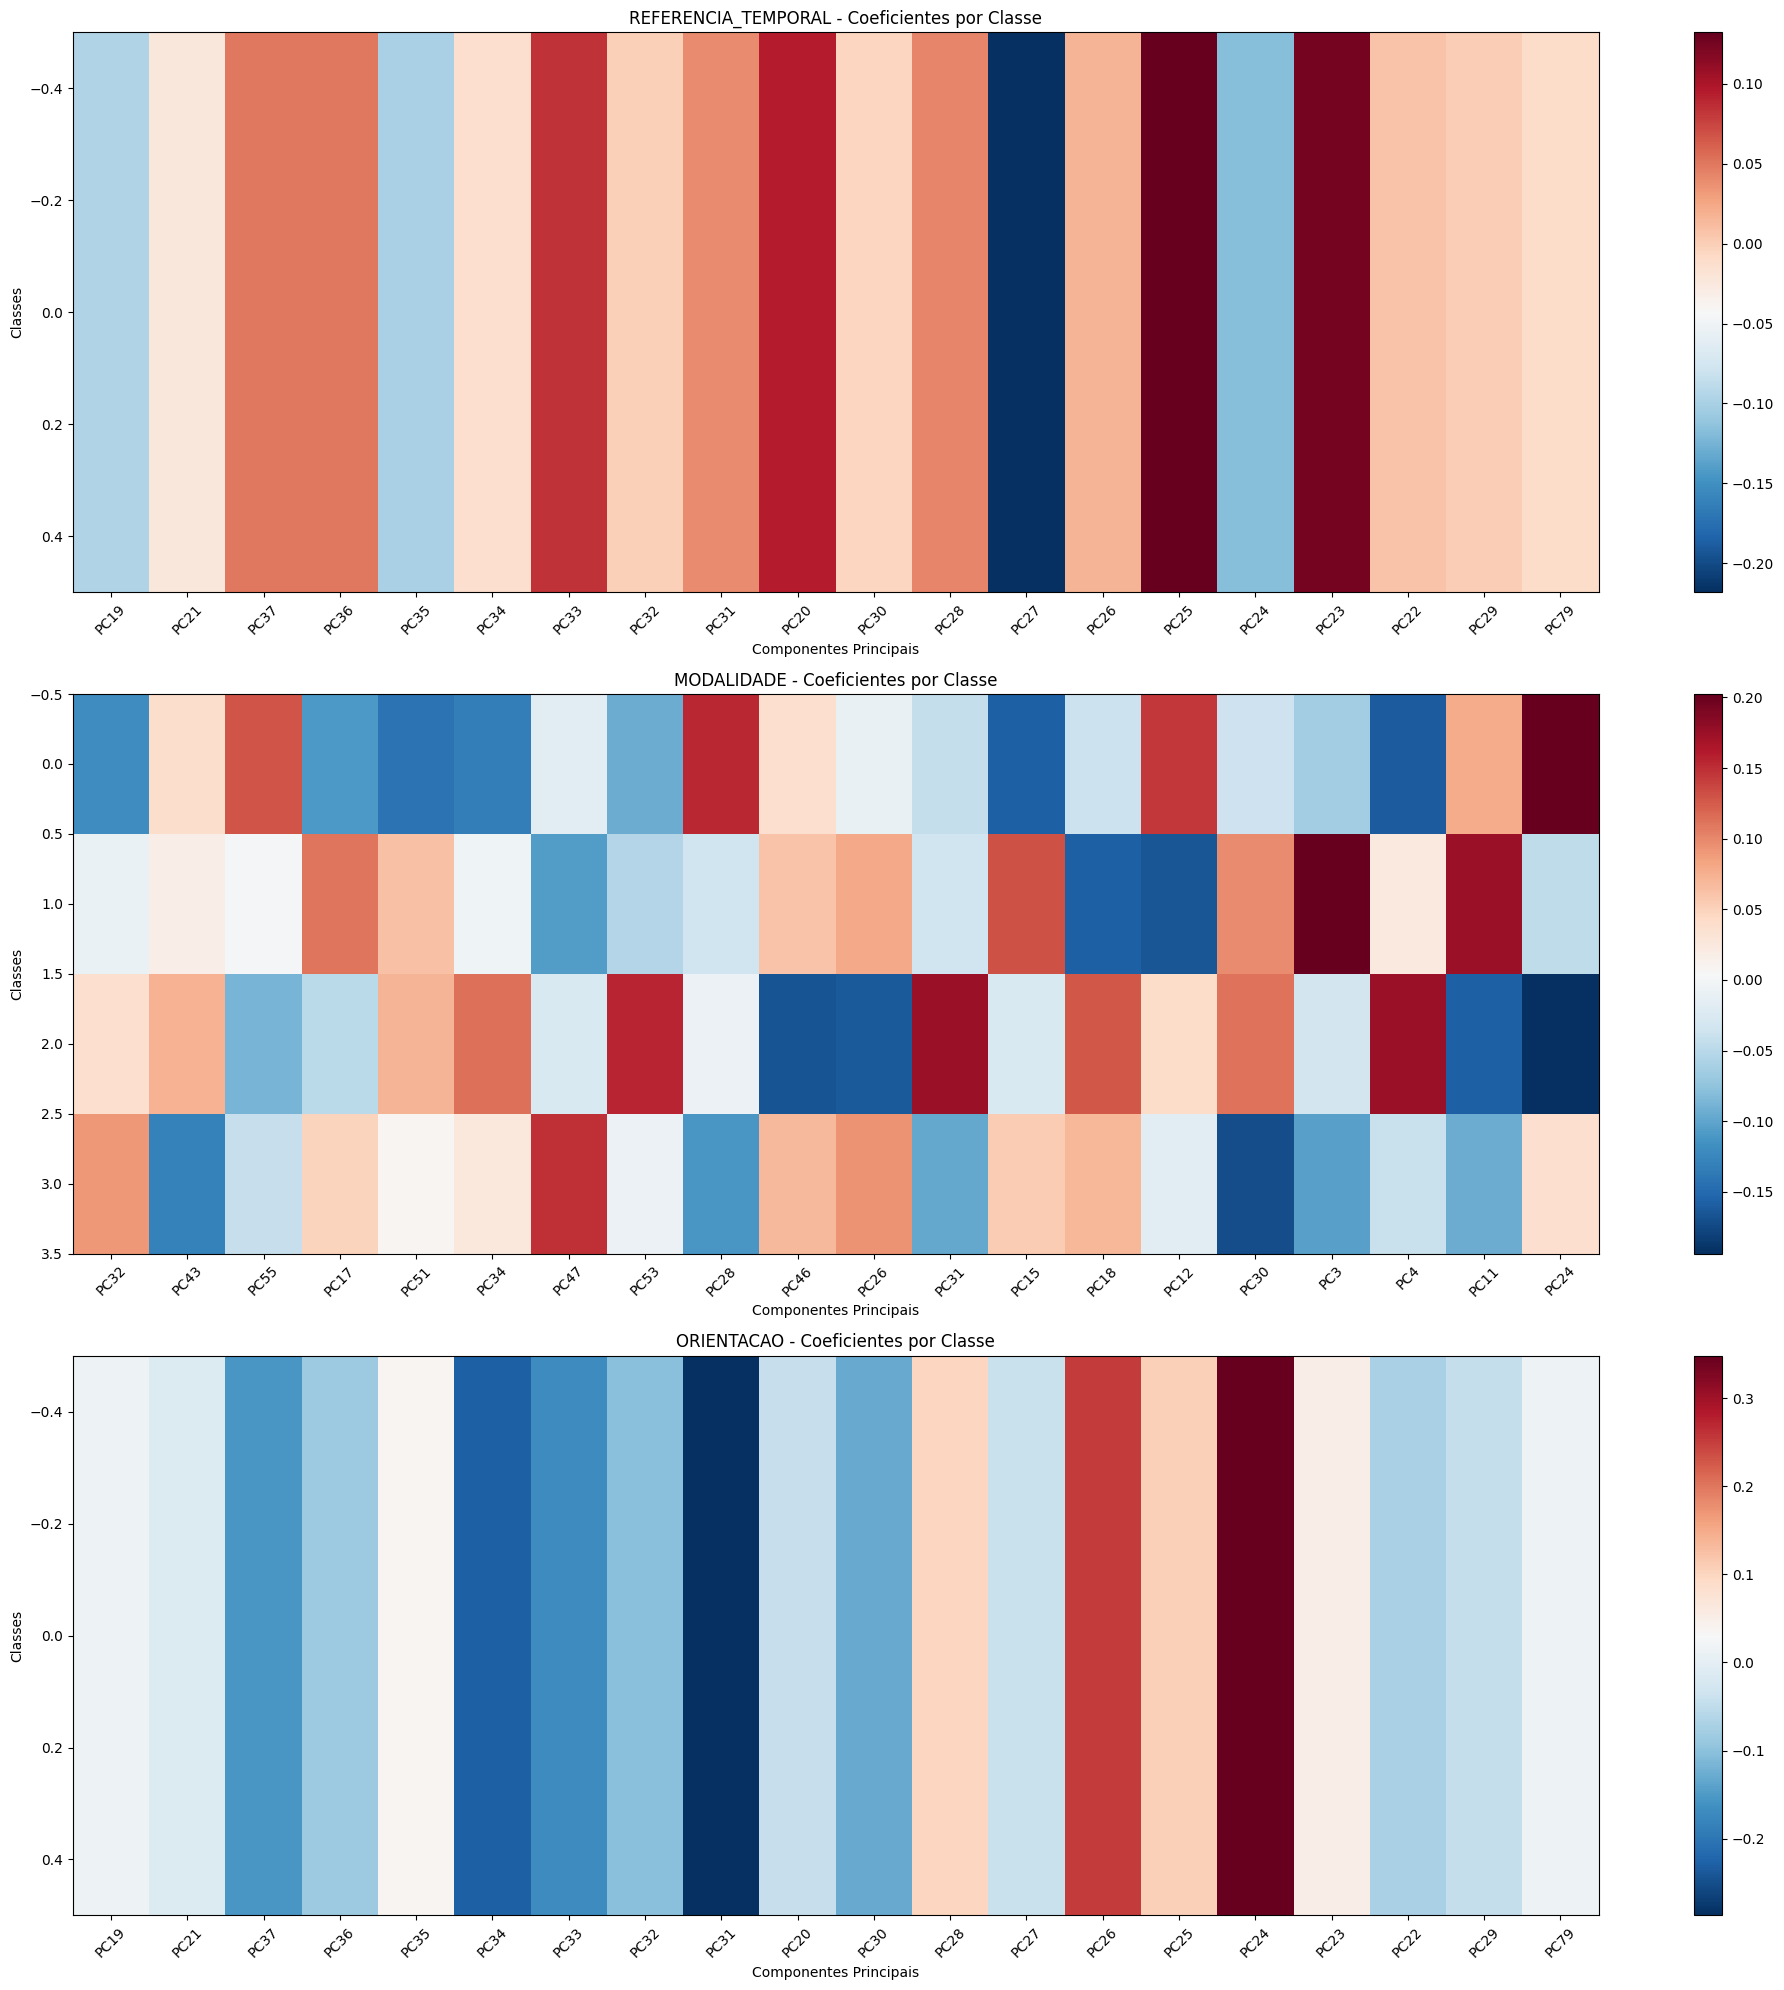

In [802]:
fig, axes = plt.subplots(3, 1, figsize=(20, 20))

for i, (task_name, clf) in enumerate(classifiers.items()):
    feature_importance = np.std(clf.coef_, axis=0) 
    top_indices = np.argsort(feature_importance)[-20:] 

    coef_subset = clf.coef_[:, top_indices]
    im = axes[i].imshow(coef_subset, cmap='RdBu_r', aspect='auto')
    
    axes[i].set_title(f'{task_name.upper()} - Coeficientes por Classe')
    axes[i].set_ylabel('Classes')
    axes[i].set_xlabel('Componentes Principais')
    axes[i].set_xticks(range(20))
    axes[i].set_xticklabels([f'PC{idx+1}' for idx in top_indices], rotation=45)
    
    plt.colorbar(im, ax=axes[i])

plt.tight_layout()
plt.show()


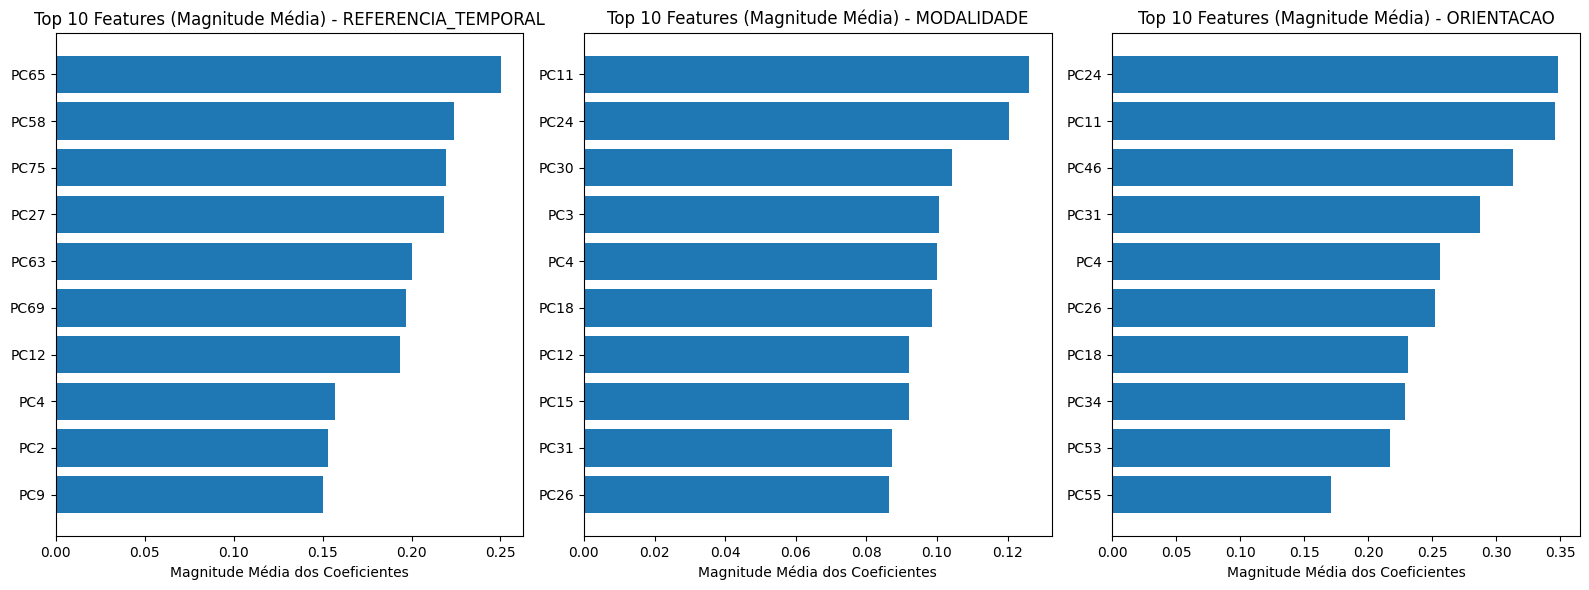

In [803]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for i, (task_name, clf) in enumerate(classifiers.items()):
    # Média da magnitude dos coeficientes entre todas as classes
    coefs_mean = np.mean(np.abs(clf.coef_), axis=0)
    top_indices = np.argsort(coefs_mean)[-10:]
    
    axes[i].barh(range(10), coefs_mean[top_indices])
    axes[i].set_title(f'Top 10 Features (Magnitude Média) - {task_name.upper()}')
    axes[i].set_xlabel('Magnitude Média dos Coeficientes')
    axes[i].set_yticks(range(10))
    axes[i].set_yticklabels([f'PC{idx+1}' for idx in top_indices])

plt.tight_layout()
plt.show()


In [804]:
def entity_type_to_onehot(entity_type, ohe_encoder):
    try:
        onehot = ohe_encoder.transform([[entity_type]])[0].tolist()
        return onehot
    except:
        return [0.0] * len(ohe_encoder.categories_[0])


In [805]:
def predictions_to_labels(predictions, encoders):
    return {
        'referencia_temporal': encoders['referencia_temporal_label'].inverse_transform([predictions['referencia_temporal']])[0],
        'modalidade': encoders['modalidade_label'].inverse_transform([predictions['modalidade']])[0], 
        'orientacao': encoders['orientacao_label'].inverse_transform([predictions['orientacao']])[0]
    }


In [806]:
def pipeline_inf(frase, ner_model, ner_tokenizer, classifiers, pca, scaler, ohe_encoder, label_encoders):
    ner = pipeline("token-classification", model=ner_model, tokenizer=ner_tokenizer, aggregation_strategy="simple")
    entidades = ner(frase)
    
    resultados = []
    
    for ent in entidades:
        examples_batch = {
            "text": [frase], 
            "start": [ent['start']], 
            "end": [ent['end']] 
        }
        
        dados_encoded = encode_and_extract_spans(examples_batch)
        features = extract_entity_features(
            ner_model.bert,
            dados_encoded['input_ids'][0],
            dados_encoded['attention_mask'][0],
            dados_encoded['span_token_indices'][0],
            entity_type_to_onehot(ent['entity_group'], ohe_encoder)
        )
        
        features_scaled = scaler.transform([features.cpu().numpy()])
        features_reduced = pca.transform(features_scaled)
        
        predictions = {}
        scores = {}
        for task_name, clf in classifiers.items():
            predictions[task_name] = clf.predict(features_reduced)[0]
            scores[task_name] = clf.predict_proba(features_reduced)[0]

        labels = predictions_to_labels(predictions, label_encoders)
        
        resultado = {
            'texto': ent['word'],
            'entidade': ent['entity_group'],
            'referencia_temporal': labels['referencia_temporal'],
            'modalidade': labels['modalidade'], 
            'orientacao': labels['orientacao'],
            'score_ner': ent['score'],
            'score': scores
        }
        resultados.append(resultado)
    return resultados 


In [807]:
frases = ["600 ta muito caro", "Nao consigo pagar esse mes, so mes que vem", "podemos fazer em 3x de 50?", "nao consigo, perdi o emprego"]

for frase in frases:
    resultados = pipeline_inf(frase, model, tokenizer, classifiers, pca, scaler, ohe, encoders) 
    print("RESULTADOS:")
    print("-" * 70)
    for i, res in enumerate(resultados, 1):
        print(f"{i}. {'**' + res['texto'] + '**':30} -> {res['entidade']:16} (score: {res['score_ner']:.2f})")
        print(f"   Referencia Temporal {'':10} -> {res['referencia_temporal'].upper():16} (score: {max(res['score']['referencia_temporal']):.2f})")
        print(f"   Modalidade {'':19} -> {res['modalidade'].upper():16} (score: {max(res['score']['modalidade']):.2f})")
        print(f"   Orientacao {'':19} -> {res['orientacao'].upper():16} (score: {max(res['score']['orientacao']):.2f})")
        print()
        

Device set to use cuda:0
Device set to use cuda:0


RESULTADOS:
----------------------------------------------------------------------
1. **600**                        -> VALOR            (score: 0.95)
   Referencia Temporal            -> PRESENTE         (score: 1.00)
   Modalidade                     -> NEGADO           (score: 1.00)
   Orientacao                     -> NEGATIVA         (score: 1.00)

2. **caro**                       -> CONDICAO         (score: 0.73)
   Referencia Temporal            -> PRESENTE         (score: 1.00)
   Modalidade                     -> NEGADO           (score: 1.00)
   Orientacao                     -> NEGATIVA         (score: 1.00)



Device set to use cuda:0
Device set to use cuda:0


RESULTADOS:
----------------------------------------------------------------------
1. **consigo**                    -> PAGAMENTO        (score: 0.91)
   Referencia Temporal            -> PRESENTE         (score: 1.00)
   Modalidade                     -> NEGADO           (score: 1.00)
   Orientacao                     -> NEGATIVA         (score: 1.00)

2. **pagar**                      -> PAGAMENTO        (score: 0.97)
   Referencia Temporal            -> PRESENTE         (score: 1.00)
   Modalidade                     -> NEGADO           (score: 0.86)
   Orientacao                     -> NEGATIVA         (score: 0.79)

3. **esse mes**                   -> TEMPO            (score: 0.99)
   Referencia Temporal            -> FUTURO           (score: 0.95)
   Modalidade                     -> NEGADO           (score: 0.73)
   Orientacao                     -> NEGATIVA         (score: 0.57)

4. **mes que vem**                -> TEMPO            (score: 0.98)
   Referencia Temporal        

In [808]:
for task_name, clf in classifiers.items():
    # Pegar algumas amostras de treino
    sample_features = X_reduced[:10]
    probabilities = clf.predict_proba(sample_features)
    
    print(f"\n{task_name}:")
    print(f"  Min probability: {probabilities.min():.6f}")
    print(f"  Max probability: {probabilities.max():.6f}")
    print(f"  Samples with prob > 0.99: {(probabilities.max(axis=1) > 0.99).sum()}/10")
    print(f"  Samples with prob > 0.999: {(probabilities.max(axis=1) > 0.999).sum()}/10")
    
    # Mostrar algumas probabilidades
    print(f"  First 3 max probabilities: {probabilities.max(axis=1)[:3]}")



referencia_temporal:
  Min probability: 0.000005
  Max probability: 0.999995
  Samples with prob > 0.99: 9/10
  Samples with prob > 0.999: 7/10
  First 3 max probabilities: [0.99999    0.99993166 0.99992516]

modalidade:
  Min probability: 0.000002
  Max probability: 0.999739
  Samples with prob > 0.99: 8/10
  Samples with prob > 0.999: 2/10
  First 3 max probabilities: [0.9848131  0.99627096 0.99233891]

orientacao:
  Min probability: 0.000442
  Max probability: 0.999558
  Samples with prob > 0.99: 7/10
  Samples with prob > 0.999: 3/10
  First 3 max probabilities: [0.94011759 0.99955773 0.93428188]


In [809]:
def gerar_relatorio(frase, entidades):
    """Versão corrigida do gerador de relatório"""
    relatorio = f"Frase: \"{frase}\"\n"

    for ent in entidades:
        texto = ent['texto']
        ent_label = ent['entidade']
        tempo = ent.get('referencia_temporal', '')
        modalidade = ent.get('modalidade', '')
        orientacao = ent.get('orientacao', '')

        # Descrição do tempo quando ausente
        if tempo == 'presente':
            tempo_desc = "agora"
        elif tempo == 'futuro':
            tempo_desc = "no futuro"
        elif tempo == 'passado':
            tempo_desc = "no passado"
        else:
            tempo_desc = ""

        # Mapeamento da orientação
        if orientacao == 'negativa':
            pode = "não pode"
        elif orientacao == 'positiva':
            pode = "pode"
        elif orientacao == 'neutra':
            pode = "poderia"
        else:
            pode = ""

        if ent_label == 'PAGAMENTO':
            if modalidade == 'afirmado':
                relatorio += f"A pessoa diz que {pode} pagar {tempo_desc}.\n"
            elif modalidade == 'negado':
                relatorio += f"A pessoa diz que {pode} pagar {tempo_desc}.\n"
            elif modalidade == 'condicional':
                relatorio += f"A pessoa diz que {pode} pagar dada a condição.\n"
            elif modalidade == 'incerto':
                relatorio += f"A pessoa diz que {pode} pagar, mas expressa incerteza sobre o ato.\n"
            elif modalidade == 'planejado':
                relatorio += f"A pessoa diz que {pode} pagar, mas isso está planejado para algum momento futuro.\n"

        elif ent_label == 'VALOR':
            if modalidade == 'condicional':
                relatorio += f"A pessoa coloca como condição o valor \"{texto}\" para pagar {tempo_desc}.\n"
            elif modalidade == 'incerto':
                relatorio += f"A pessoa diz que {pode} pagar o valor \"{texto}\", mas expressa incerteza.\n"
            elif modalidade == 'planejado':
                relatorio += f"A pessoa planeja pagar o valor \"{texto}\" no futuro.\n"
            else:
                relatorio += f"A pessoa diz que {pode} pagar o valor \"{texto}\" {tempo_desc}.\n"

        elif ent_label == 'TEMPO':
            if modalidade == 'condicional':
                relatorio += f"A pessoa menciona que {pode} pagar em \"{texto}\" dada a condição.\n"
            elif modalidade == 'incerto':
                relatorio += f"A pessoa diz que {pode} pagar em \"{texto}\", mas está incerta.\n"
            elif modalidade == 'planejado':
                relatorio += f"A pessoa planeja pagar em \"{texto}\" no futuro.\n"
            else:
                relatorio += f"A pessoa diz que {pode} pagar em \"{texto}\", mencionado como \"{texto}\".\n"

        elif ent_label == 'CONDICAO':
            if modalidade == 'condicional':
                relatorio += f"A pessoa define a condição \"{texto}\" como {"requisito" if orientacao == 'positiva' else "impeditivo"} para pagar.\n"
            elif modalidade == 'incerto':
                relatorio += f"A pessoa expressa incerteza sobre pagar, mencionando a condição \"{texto}\".\n"
            elif modalidade == 'planejado':
                relatorio += f"A pessoa planeja pagar desde que a condição \"{texto}\" seja atendida no futuro.\n"
            else:
                relatorio += f"A pessoa diz que {pode} pagar sob a condição \"{texto}\".\n"

    return relatorio


In [810]:
resultados = {}
for frase in ["nao consigo","consigo","posso pagar 780?", "semana que vem prometo pagar", "nao consigo, perdi o emprego","quero quitar essa divida", "vamos fazer 3x sem juros", "nao consigo pagar esse mes, so mes que vem"]:
    resultados[frase] = pipeline_inf(frase, model, tokenizer, classifiers, pca, scaler, ohe, encoders)



Device set to use cuda:0
Device set to use cuda:0
Device set to use cuda:0
Device set to use cuda:0
Device set to use cuda:0
Device set to use cuda:0
Device set to use cuda:0
Device set to use cuda:0


In [811]:
resultados


{'nao consigo': [{'texto': 'consigo',
   'entidade': 'PAGAMENTO',
   'referencia_temporal': 'presente',
   'modalidade': 'negado',
   'orientacao': 'negativa',
   'score_ner': 0.99245,
   'score': {'referencia_temporal': array([1.04456299e-04, 9.99895544e-01]),
    'modalidade': array([2.11739054e-03, 6.17807608e-03, 9.91704061e-01, 4.72853296e-07]),
    'orientacao': array([0.99536511, 0.00463489])}}],
 'consigo': [{'texto': 'consigo',
   'entidade': 'PAGAMENTO',
   'referencia_temporal': 'presente',
   'modalidade': 'afirmado',
   'orientacao': 'positiva',
   'score_ner': 0.98858005,
   'score': {'referencia_temporal': array([3.92441013e-04, 9.99607559e-01]),
    'modalidade': array([9.99593207e-01, 4.05799227e-04, 9.80110270e-07, 1.35713010e-08]),
    'orientacao': array([1.10939565e-04, 9.99889060e-01])}}],
 'posso pagar 780?': [{'texto': 'pagar',
   'entidade': 'PAGAMENTO',
   'referencia_temporal': 'presente',
   'modalidade': 'condicional',
   'orientacao': 'positiva',
   'score

In [812]:

for frase in resultados.keys():
    print(f'{60*'-'}')
    print(gerar_relatorio(frase, resultados[frase]))
    


------------------------------------------------------------
Frase: "nao consigo"
A pessoa diz que não pode pagar agora.

------------------------------------------------------------
Frase: "consigo"
A pessoa diz que pode pagar agora.

------------------------------------------------------------
Frase: "posso pagar 780?"
A pessoa diz que pode pagar dada a condição.
A pessoa coloca como condição o valor "780?" para pagar agora.

------------------------------------------------------------
Frase: "semana que vem prometo pagar"
A pessoa diz que pode pagar em "semana que vem", mencionado como "semana que vem".
A pessoa diz que pode pagar agora.
A pessoa diz que pode pagar dada a condição.

------------------------------------------------------------
Frase: "nao consigo, perdi o emprego"
A pessoa diz que não pode pagar agora.
A pessoa diz que não pode pagar sob a condição "perd".
A pessoa diz que não pode pagar agora.
A pessoa diz que não pode pagar sob a condição "o emprego".

------------

In [813]:

pipeline_components_dill = {
    'model': model,
    'tokenizer': tokenizer, 
    'classifiers': classifiers,
    'pca': pca,
    'scaler': scaler,
    'ohe_encoder': ohe,
    'label_encoders': encoders,
    'pipeline_function': pipeline_inf,
    'helper_functions': {
        'entity_type_to_onehot': entity_type_to_onehot,
        'predictions_to_labels': predictions_to_labels,
        'encode_and_extract_spans': encode_and_extract_spans,
        'extract_entity_features': extract_entity_features,
        'gerar_relatorio': gerar_relatorio
    }
}

with open('../model/ner_bert_dill.pkl', 'wb') as f:
    dill.dump(pipeline_components_dill, f)

print(f"Tamanho do arquivo: {os.path.getsize('../model/ner_bert_dill.pkl') / (1024*1024):.2f} MB")



Tamanho do arquivo: 415.28 MB
